# Dataset reshape: flat → night-major

One-time, out-of-band reshape of the raw **flat** transmission file into the
**night-major** file the training pipeline consumes:

| | file | datasets |
|---|---|---|
| flat (in) | `data/telluric_templates.h5` | `transmission (n_flat, N)`, `labels (n_flat, P)` |
| night-major (out) | `data/telluric_timeseries/telluric_templates.h5` | `transmission (n_nights, T, N)`, `labels (n_nights, T, P)` |

The flat file is **series-major**: rows `[0:T]` are night 0, `[T:2T]` night 1, and so on.
`build_timeseries_h5` streams it once and writes whole nights.

This used to be triggered from `train.py` via `--build`; it lives here now so that
training never reshapes on the go.

Run the cells top to bottom.

In [7]:
from pathlib import Path
import sys

import h5py
import numpy as np
import matplotlib.pyplot as plt

# The notebook lives in Tellurics/tests/. Resolve the repo root (works whether the
# kernel cwd is the repo root or tests/) and make the src-layout package importable.
REPO_ROOT = Path("/home/mvasist/Documents/Tellurics_data/")

DATA_DIR = REPO_ROOT / "telluric_timeseries"
FLAT_H5 = DATA_DIR / "telluric_templates.h5"              # input (flat)
NIGHT_H5 = DATA_DIR / "telluric_templates_nights.h5"     # output (night-major)

print("repo root:", REPO_ROOT)
print("flat  h5 :", FLAT_H5, "| exists:", FLAT_H5.exists())
print("night h5 :", NIGHT_H5, "| exists:", NIGHT_H5.exists())

repo root: /home/mvasist/Documents/Tellurics_data
flat  h5 : /home/mvasist/Documents/Tellurics_data/telluric_timeseries/telluric_templates.h5 | exists: True
night h5 : /home/mvasist/Documents/Tellurics_data/telluric_timeseries/telluric_templates_nights.h5 | exists: False


## 1. Inspect the flat source file

In [8]:
def inspect_h5(path: Path) -> None:
    """Print groups/datasets, their shapes/dtypes and attributes."""
    with h5py.File(path, "r") as hf:
        print(f"===== {path} =====")
        print("file attrs:")
        for k, v in hf.attrs.items():
            print(f"  {k} = {v}")

        def _visit(name: str, obj: object) -> None:
            indent = "  " * (name.count("/") + 1)
            if isinstance(obj, h5py.Dataset):
                print(f"{indent}[dataset] {name:.<28} shape={obj.shape} dtype={obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"{indent}[group] {name}")
            for k, v in obj.attrs.items():
                print(f"{indent}  attr: {k} = {v}")

        hf.visititems(_visit)


inspect_h5(FLAT_H5)

===== /home/mvasist/Documents/Tellurics_data/telluric_timeseries/telluric_templates.h5 =====
file attrs:
  conditions_h5 = /scratch-ssd1/andy-ext/TFM_DATA/telfit/conditions/production_10000nights_variable_molecules/telfit_condition_series_variable_molecules.h5
  conditions_schema_version = 2.1
  highfreq_cm1 = 12501.562695336917
  lowfreq_cm1 = 10525.207872855488
  n_frames_per_series = 73
  padding_nm = 0.1
  spectral_config = /scratch-ssd1/andy-ext/TFM/configs/telfit_spectral_production.toml
  target_resolution = 100000.0
  wavegrid_file = /scratch-ssd1/andy-ext/TFM_DATA/phoenix/resampled/phoenix_A0V_T9600_logg4p0_fehp0p0_R100000_s3.fits
  wavelength_max_nm = 950.0
  wavelength_medium = vacuum
  wavelength_min_nm = 800.0
  [dataset] failed_indices.............. shape=(0,) dtype=int64
  [dataset] labels...................... shape=(730000, 20) dtype=float32
    attr: columns = ['flat_index' 'series_index' 'frame_index' 'time_hours' 'pressure'
 'temperature' 'humidity' 'angle' 'airmass

In [9]:
with h5py.File(FLAT_H5, "r") as hf:
    n_flat, n_wave = hf["transmission"].shape
    n_frames = int(hf.attrs.get("n_frames_per_series", 73))
    cols = [c.decode() if isinstance(c, bytes) else str(c)
            for c in hf["labels"].attrs["columns"]]
    wl = np.asarray(hf["wavelength"][:], np.float64)

n_nights = n_flat // n_frames
print(f"flat rows      : {n_flat}  (= {n_nights} nights x {n_frames} frames)")
print(f"wavelength bins: {n_wave}  ({wl.min():.3f} .. {wl.max():.3f} nm)")
print(f"label columns  : {len(cols)} -> {cols}")
assert n_flat % n_frames == 0, "flat rows not divisible by n_frames"

flat rows      : 730000  (= 10000 nights x 73 frames)
wavelength bins: 51557  (800.000 .. 950.000 nm)
label columns  : 20 -> ['flat_index', 'series_index', 'frame_index', 'time_hours', 'pressure', 'temperature', 'humidity', 'angle', 'airmass', 'co2', 'o3', 'n2o', 'co', 'ch4', 'o2', 'no', 'so2', 'no2', 'nh3', 'hno3']


## 2. Reshape (one-time, streams the multi-GB file)

Writes `NIGHT_H5` night by night. Safe to re-run: it overwrites the output.

In [10]:

def _decode_columns(columns) -> list[str]:
    """Decode an h5py 'columns' attribute into a list of strings."""
    out: list[str] = []
    for c in columns:
        if isinstance(c, bytes):
            out.append(c.decode("utf-8"))
        else:
            out.append(str(c))
    return out



In [11]:
# --------------------------------------------------------------------------- #
# Reshape the flat HDF5 into the night-major HDF5 (run once)
# --------------------------------------------------------------------------- #
def build_timeseries_h5(
    flat_h5: str | Path,
    out_h5: str | Path,
    n_frames: int | None = None,
):
    """Reshape the flat transmission file into a night-major HDF5.

    Args:
        flat_h5: Raw file with top-level datasets 'transmission' (n_flat, N),
            'labels' (n_flat, P) with attr 'columns', and 'wavelength' (N,).
        out_h5: Output night-major file:
            'transmission' (n_series, T, N), 'labels' (n_series, T, P)
            with attr 'columns', 'wavelength' (N,).
        n_frames: exposures per night (auto-read from file attrs if None).

    Returns:
        The :class:`Wavegrid` read from the source file.
    """
    import h5py

    flat_h5 = Path(flat_h5)
    out_h5 = Path(out_h5)

    with h5py.File(flat_h5, "r") as f:
        trans = f["transmission"]
        n_flat, n_wave = trans.shape
        if n_frames is None:
            n_frames = int(f.attrs.get("n_frames_per_series", 73))
        n_series = n_flat // n_frames
        if n_flat % n_frames != 0:
            raise ValueError(
                f"n_flat={n_flat} not divisible by n_frames={n_frames}"
            )
        wl = np.asarray(f["wavelength"][:], np.float64)
        n_labels = f["labels"].shape[1]
        cols = _decode_columns(f["labels"].attrs.get("columns", []))
        unit = str(f["wavelength"].attrs.get("unit", "nm"))

    out_h5.parent.mkdir(parents=True, exist_ok=True)
    with h5py.File(out_h5, "w") as o:
        o.create_dataset(
            "transmission", shape=(n_series, n_frames, n_wave),
            dtype=np.float32, chunks=(1, n_frames, min(256, n_wave)),
            compression="gzip", compression_opts=4,
        )
        o.create_dataset(
            "labels", shape=(n_series, n_frames, n_labels),
            dtype=np.float32, chunks=(1, n_frames, n_labels),
        )
        o.create_dataset("wavelength", data=wl)
        o["wavelength"].attrs["unit"] = unit
        if cols:
            o["labels"].attrs["columns"] = cols

            
        with h5py.File(flat_h5, "r") as src:
            for s in range(n_series):
                sl = slice(s * n_frames, (s + 1) * n_frames)
                o["transmission"][s] = src["transmission"][sl]
                o["labels"][s] = src["labels"][sl]
                if s % 500 == 0:
                    print(f"  series {s}/{n_series}")


In [12]:
build_timeseries_h5(FLAT_H5, NIGHT_H5)
# wavegrid

  series 0/10000


KeyboardInterrupt: 

## 3. Validate the night-major output

In [7]:
# Spot-check: night-major night s must equal flat rows [s*T, (s+1)*T).
check_nights = [0, 1, n_nights // 2, n_nights - 1]
with h5py.File(NIGHT_H5, "r") as night, h5py.File(FLAT_H5, "r") as flat:
    for s in check_nights:
        sl = slice(s * n_frames, (s + 1) * n_frames)
        t_ok = np.array_equal(night["transmission"][s], flat["transmission"][sl])
        l_ok = np.array_equal(night["labels"][s], flat["labels"][sl])
        print(f"night {s:>5}: transmission match={t_ok}, labels match={l_ok}")

    print("night transmission:", night["transmission"].shape, night["transmission"].dtype)
    print("night labels      :", night["labels"].shape, night["labels"].dtype)
    print("wavelength unit   :", night["wavelength"].attrs.get("unit"))
    print("label columns     :", [c.decode() if isinstance(c, bytes) else str(c)
                                  for c in night["labels"].attrs["columns"]])

night     0: transmission match=True, labels match=True
night     1: transmission match=True, labels match=True
night  2250: transmission match=True, labels match=True
night  4499: transmission match=True, labels match=True
night transmission: (4500, 73, 51556) float32
night labels      : (4500, 73, 20) float32
wavelength unit   : nm
label columns     : ['flat_index', 'series_index', 'frame_index', 'time_hours', 'pressure', 'temperature', 'humidity', 'angle', 'airmass', 'co2', 'o3', 'n2o', 'co', 'ch4', 'o2', 'no', 'so2', 'no2', 'nh3', 'hno3']


## 4. Quick sanity plot

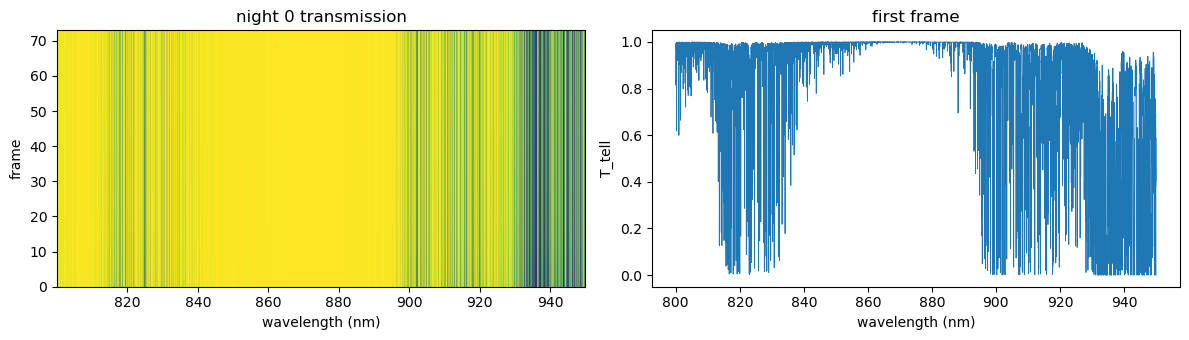

In [8]:
night_idx = 0
with h5py.File(NIGHT_H5, "r") as hf:
    trans = np.asarray(hf["transmission"][night_idx])   # (T, N)
    wl_out = np.asarray(hf["wavelength"][:], np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].imshow(trans, aspect="auto", origin="lower",
               extent=[wl_out[0], wl_out[-1], 0, trans.shape[0]])
axes[0].set(xlabel="wavelength (nm)", ylabel="frame",
            title=f"night {night_idx} transmission")
axes[1].plot(wl_out, trans[0], lw=0.6)
axes[1].set(xlabel="wavelength (nm)", ylabel="T_tell", title="first frame")
fig.tight_layout()
plt.show()

In [9]:
937/60

15.616666666666667